# House Price Prediction using Linear Regression

## NeuroFive ML Track - Week 2 Task 2

**Author:** Muhammad Fahad

### Objective

In this notebook, I build a Linear Regression model to predict house prices. I select important features, train the model, evaluate its performance, and explain the results in simple language.''

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(20640, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
features = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population"]

X = df[features]

y = df["Price"]

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population
0,8.3252,41.0,6.984127,1.023810,322.0
1,8.3014,21.0,6.238137,0.971880,2401.0
2,7.2574,52.0,8.288136,1.073446,496.0
3,5.6431,52.0,5.817352,1.073059,558.0
4,3.8462,52.0,6.281853,1.081081,565.0


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (14448, 5)
Testing Data: (6192, 5)


In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [8]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1.01158742 1.56067396 2.65915771 2.64416281 1.98031269 2.17307739
 2.65410105 2.16605501 2.41863406 4.21198421]


In [9]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.7859647054435119
R² Score: 0.5293549396888139


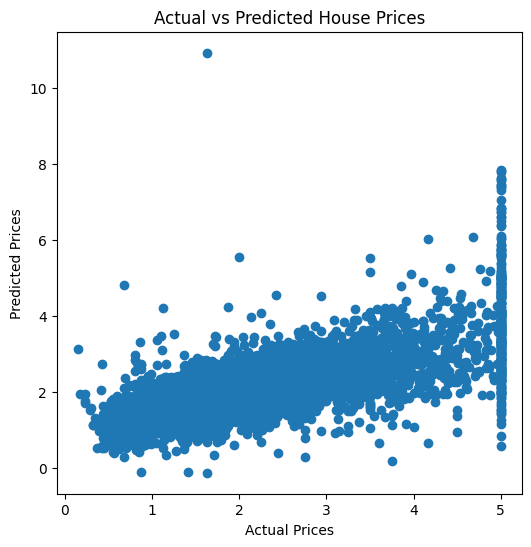

In [10]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

## Model Interpretation

The Linear Regression model was trained using five important features.

The RMSE value shows the average prediction error of the model. A lower RMSE indicates better performance.

The R² score tells us how well the selected features explain house prices. A higher R² score means the model predicts prices more accurately.

## R² Score Explained in Simple Words

The R² score shows how well the model understands the relationship between house features and house prices.

For example, if the R² score is 0.60, it means the model can explain about 60% of the changes in house prices using the selected features.

A higher R² score means the predictions are generally more reliable, while a lower score means there are other factors affecting house prices that the model has not learned.

## R² Score Explained in Simple Words

My model achieved an **R² Score of 0.529**.

This means the model can explain about **53% of the changes in house prices** using the selected features.

The remaining variation depends on other factors that were not included in the model.

Overall, the model provides a good starting point for predicting house prices.

# Conclusion

In this project, I built a Linear Regression model to predict house prices using five important features.

The model achieved an **RMSE of 0.786** and an **R² Score of 0.529**, indicating that it explains approximately **53%** of the variation in house prices.

This project helped me understand regression, model evaluation, and how machine learning can be used to predict continuous numerical values.